# Euchre Data Analysis Notebook

This notebook provides tools for analyzing euchre game data, including:
- Game result analysis
- Player performance metrics
- Strategy effectiveness evaluation
- Statistical insights and visualizations

## Setup and Imports

In [1]:
import sys
import os
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Add the parent directory to the path to import euchre modules
sys.path.append(str(Path.cwd().parent))

from euchre.mass_game_runner import MassGameRunner
from euchre.game_logger import GameLogger
from euchre.models import PlayerType, Card, Suit, Rank

print("✅ Imports successful")

✅ Imports successful


## Initialize Data Sources

In [2]:
# Initialize mass game runner to access game data
runner = MassGameRunner()

# Check for existing game data
game_files = runner.get_game_files()
print(f"📊 Found {len(game_files)} game result files")

# Check for game log files in the parent directory
parent_dir = Path.cwd().parent
log_files = list(parent_dir.glob("euchre_game_*.txt"))
print(f"📝 Found {len(log_files)} game log files")

print(f"\n📁 Game results directory: {runner.output_dir}")
print(f"📁 Game logs directory: {parent_dir}")

📊 Found 2000 game result files
📝 Found 0 game log files

📁 Game results directory: games
📁 Game logs directory: /projects/vibe_eucher


## Load Game Results Data

In [3]:
# Load game results from JSON files
game_results = []
failed_games = 0

for game_file in game_files:
    try:
        with open(game_file, 'r') as f:
            game_data = json.load(f)
            if 'error' not in game_data:
                game_results.append(game_data)
            else:
                failed_games += 1
    except Exception as e:
        print(f"⚠️  Error loading {game_file}: {e}")
        failed_games += 1

print(f"✅ Successfully loaded {len(game_results)} completed games")
if failed_games > 0:
    print(f"⚠️  Failed to load {failed_games} games")

if game_results:
    print(f"\n📋 Sample game data keys: {list(game_results[0].keys())}")
    print(f"🎮 First game: {game_results[0]['team_config']} - {game_results[0]['winner']} wins")

✅ Successfully loaded 1250 completed games
⚠️  Failed to load 750 games

📋 Sample game data keys: ['game_id', 'timestamp', 'team_config', 'team1', 'team2', 'winner', 'total_rounds', 'rounds', 'game_duration']
🎮 First game: aggressive_vs_balanced - team2 wins


## Convert to DataFrame for Analysis

In [4]:
if game_results:
    # Extract key data for analysis
    analysis_data = []
    for game in game_results:
        analysis_data.append({
            'game_id': game['game_id'],
            'timestamp': game['timestamp'],
            'config': game['team_config'],
            'winner': game['winner'],
            'team1_score': game['team1']['final_score'],
            'team2_score': game['team2']['final_score'],
            'total_rounds': game['total_rounds'],
            'game_duration': game['game_duration'],
            'team1_players': str(game['team1']['players']),
            'team2_players': str(game['team2']['players'])
        })
    
    df = pd.DataFrame(analysis_data)
    
    # Convert timestamp to datetime
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
    df['date'] = df['datetime'].dt.date
    df['hour'] = df['datetime'].dt.hour
    
    print(f"📊 DataFrame created with {len(df)} games")
    print(f"\n📋 Columns: {list(df.columns)}")
    print(f"\n📅 Date range: {df['date'].min()} to {df['date'].max()}")
    
    df.head()
else:
    print("⚠️  No game results available for analysis")

📊 DataFrame created with 1250 games

📋 Columns: ['game_id', 'timestamp', 'config', 'winner', 'team1_score', 'team2_score', 'total_rounds', 'game_duration', 'team1_players', 'team2_players', 'datetime', 'date', 'hour']

📅 Date range: 2025-08-12 to 2025-08-12


## Basic Game Statistics

In [5]:
if 'df' in locals() and len(df) > 0:
    print("📊 BASIC GAME STATISTICS")
    print("=" * 50)
    
    # Overall win rates
    total_games = len(df)
    team1_wins = len(df[df['winner'] == 'team1'])
    team2_wins = len(df[df['winner'] == 'team2'])
    ties = len(df[df['winner'] == 'tie'])
    
    print(f"🎮 Total Games: {total_games}")
    print(f"🏆 Team1 Wins: {team1_wins} ({team1_wins/total_games:.1%})")
    print(f"🎯 Team2 Wins: {team2_wins} ({team2_wins/total_games:.1%})")
    if ties > 0:
        print(f"🤝 Ties: {ties} ({ties/total_games:.1%})")
    
    # Game length statistics
    print(f"\n⏱️  Game Length:")
    print(f"  Average: {df['total_rounds'].mean():.1f} rounds")
    print(f"  Median: {df['total_rounds'].median():.1f} rounds")
    print(f"  Min: {df['total_rounds'].min()} rounds")
    print(f"  Max: {df['total_rounds'].max()} rounds")
    print(f"  Std Dev: {df['total_rounds'].std():.1f} rounds")
    
    # Score statistics
    print(f"\n📈 Scores:")
    print(f"  Team1 Avg: {df['team1_score'].mean():.1f} ± {df['team1_score'].std():.1f}")
    print(f"  Team2 Avg: {df['team2_score'].mean():.1f} ± {df['team2_score'].std():.1f}")
    print(f"  Highest Score: {max(df['team1_score'].max(), df['team2_score'].max())}")
    print(f"  Lowest Score: {min(df['team1_score'].min(), df['team2_score'].min())}")
    
    # Game duration
    print(f"\n⏰ Game Duration:")
    print(f"  Average: {df['game_duration'].mean():.2f} seconds")
    print(f"  Total Time: {df['game_duration'].sum()/3600:.1f} hours")

📊 BASIC GAME STATISTICS
🎮 Total Games: 1250
🏆 Team1 Wins: 603 (48.2%)
🎯 Team2 Wins: 647 (51.8%)

⏱️  Game Length:
  Average: 16.4 rounds
  Median: 17.0 rounds
  Min: 10 rounds
  Max: 19 rounds
  Std Dev: 2.0 rounds

📈 Scores:
  Team1 Avg: 8.2 ± 2.3
  Team2 Avg: 8.3 ± 2.3
  Highest Score: 10
  Lowest Score: 0

⏰ Game Duration:
  Average: 3.06 seconds
  Total Time: 1.1 hours


## Configuration Analysis

In [6]:
if 'df' in locals() and len(df) > 0:
    print("📊 CONFIGURATION ANALYSIS")
    print("=" * 50)
    
    # Analyze each configuration
    config_stats = {}
    
    for config_name in df['config'].unique():
        config_df = df[df['config'] == config_name]
        
        team1_wins = len(config_df[config_df['winner'] == 'team1'])
        team2_wins = len(config_df[config_df['winner'] == 'team2'])
        ties = len(config_df[config_df['winner'] == 'tie'])
        total = len(config_df)
        
        config_stats[config_name] = {
            'total_games': total,
            'team1_wins': team1_wins,
            'team2_wins': team2_wins,
            'ties': ties,
            'team1_win_rate': team1_wins / total,
            'team2_win_rate': team2_wins / total,
            'avg_rounds': config_df['total_rounds'].mean(),
            'avg_duration': config_df['game_duration'].mean()
        }
        
        print(f"\n🎯 {config_name}:")
        print(f"  🎮 Games: {total}")
        print(f"  🏆 Team1: {team1_wins}/{total} ({team1_wins/total:.1%})")
        print(f"  🎯 Team2: {team2_wins}/{total} ({team2_wins/total:.1%})")
        if ties > 0:
            print(f"  🤝 Ties: {ties}/{total} ({ties/total:.1%})")
        print(f"  ⏱️  Avg Rounds: {config_df['total_rounds'].mean():.1f}")
        print(f"  ⏰ Avg Duration: {config_df['game_duration'].mean():.2f}s")

📊 CONFIGURATION ANALYSIS

🎯 aggressive_vs_balanced:
  🎮 Games: 250
  🏆 Team1: 126/250 (50.4%)
  🎯 Team2: 124/250 (49.6%)
  ⏱️  Avg Rounds: 16.3
  ⏰ Avg Duration: 2.64s

🎯 opportunistic_vs_aggressive:
  🎮 Games: 250
  🏆 Team1: 112/250 (44.8%)
  🎯 Team2: 138/250 (55.2%)
  ⏱️  Avg Rounds: 16.6
  ⏰ Avg Duration: 2.73s

🎯 aggressive_vs_conservative:
  🎮 Games: 250
  🏆 Team1: 125/250 (50.0%)
  🎯 Team2: 125/250 (50.0%)
  ⏱️  Avg Rounds: 16.3
  ⏰ Avg Duration: 3.21s

🎯 mixed_vs_mixed:
  🎮 Games: 250
  🏆 Team1: 119/250 (47.6%)
  🎯 Team2: 131/250 (52.4%)
  ⏱️  Avg Rounds: 16.3
  ⏰ Avg Duration: 2.83s

🎯 conservative_vs_balanced:
  🎮 Games: 250
  🏆 Team1: 121/250 (48.4%)
  🎯 Team2: 129/250 (51.6%)
  ⏱️  Avg Rounds: 16.6
  ⏰ Avg Duration: 3.87s


## Time-based Analysis

In [7]:
if 'df' in locals() and len(df) > 0:
    print("�� TIME-BASED ANALYSIS")
    print("=" * 50)
    
    # Games per day
    daily_games = df.groupby('date').size()
    print(f"\n📅 Games per day:")
    print(f"  Most active day: {daily_games.idxmax()} ({daily_games.max()} games)")
    print(f"  Least active day: {daily_games.idxmin()} ({daily_games.min()} games)")
    print(f"  Average per day: {daily_games.mean():.1f} games")
    
    # Games per hour
    hourly_games = df.groupby('hour').size()
    print(f"\n🕐 Games per hour:")
    print(f"  Peak hour: {hourly_games.idxmax()}:00 ({hourly_games.max()} games)")
    print(f"  Quiet hour: {hourly_games.idxmin()}:00 ({hourly_games.min()} games)")
    
    # Performance over time
    print(f"\n📈 Performance trends:")
    daily_performance = df.groupby('date').agg({
        'winner': lambda x: (x == 'team1').sum() / len(x),
        'total_rounds': 'mean',
        'game_duration': 'mean'
    }).rename(columns={'winner': 'team1_win_rate'})
    
    print(f"  Team1 win rate trend: {daily_performance['team1_win_rate'].iloc[-1]:.1%} (latest) vs {daily_performance['team1_win_rate'].iloc[0]:.1%} (earliest)")

�� TIME-BASED ANALYSIS

📅 Games per day:
  Most active day: 2025-08-12 (1250 games)
  Least active day: 2025-08-12 (1250 games)
  Average per day: 1250.0 games

🕐 Games per hour:
  Peak hour: 6:00 (750 games)
  Quiet hour: 5:00 (500 games)

📈 Performance trends:
  Team1 win rate trend: 48.2% (latest) vs 48.2% (earliest)


## Visualizations

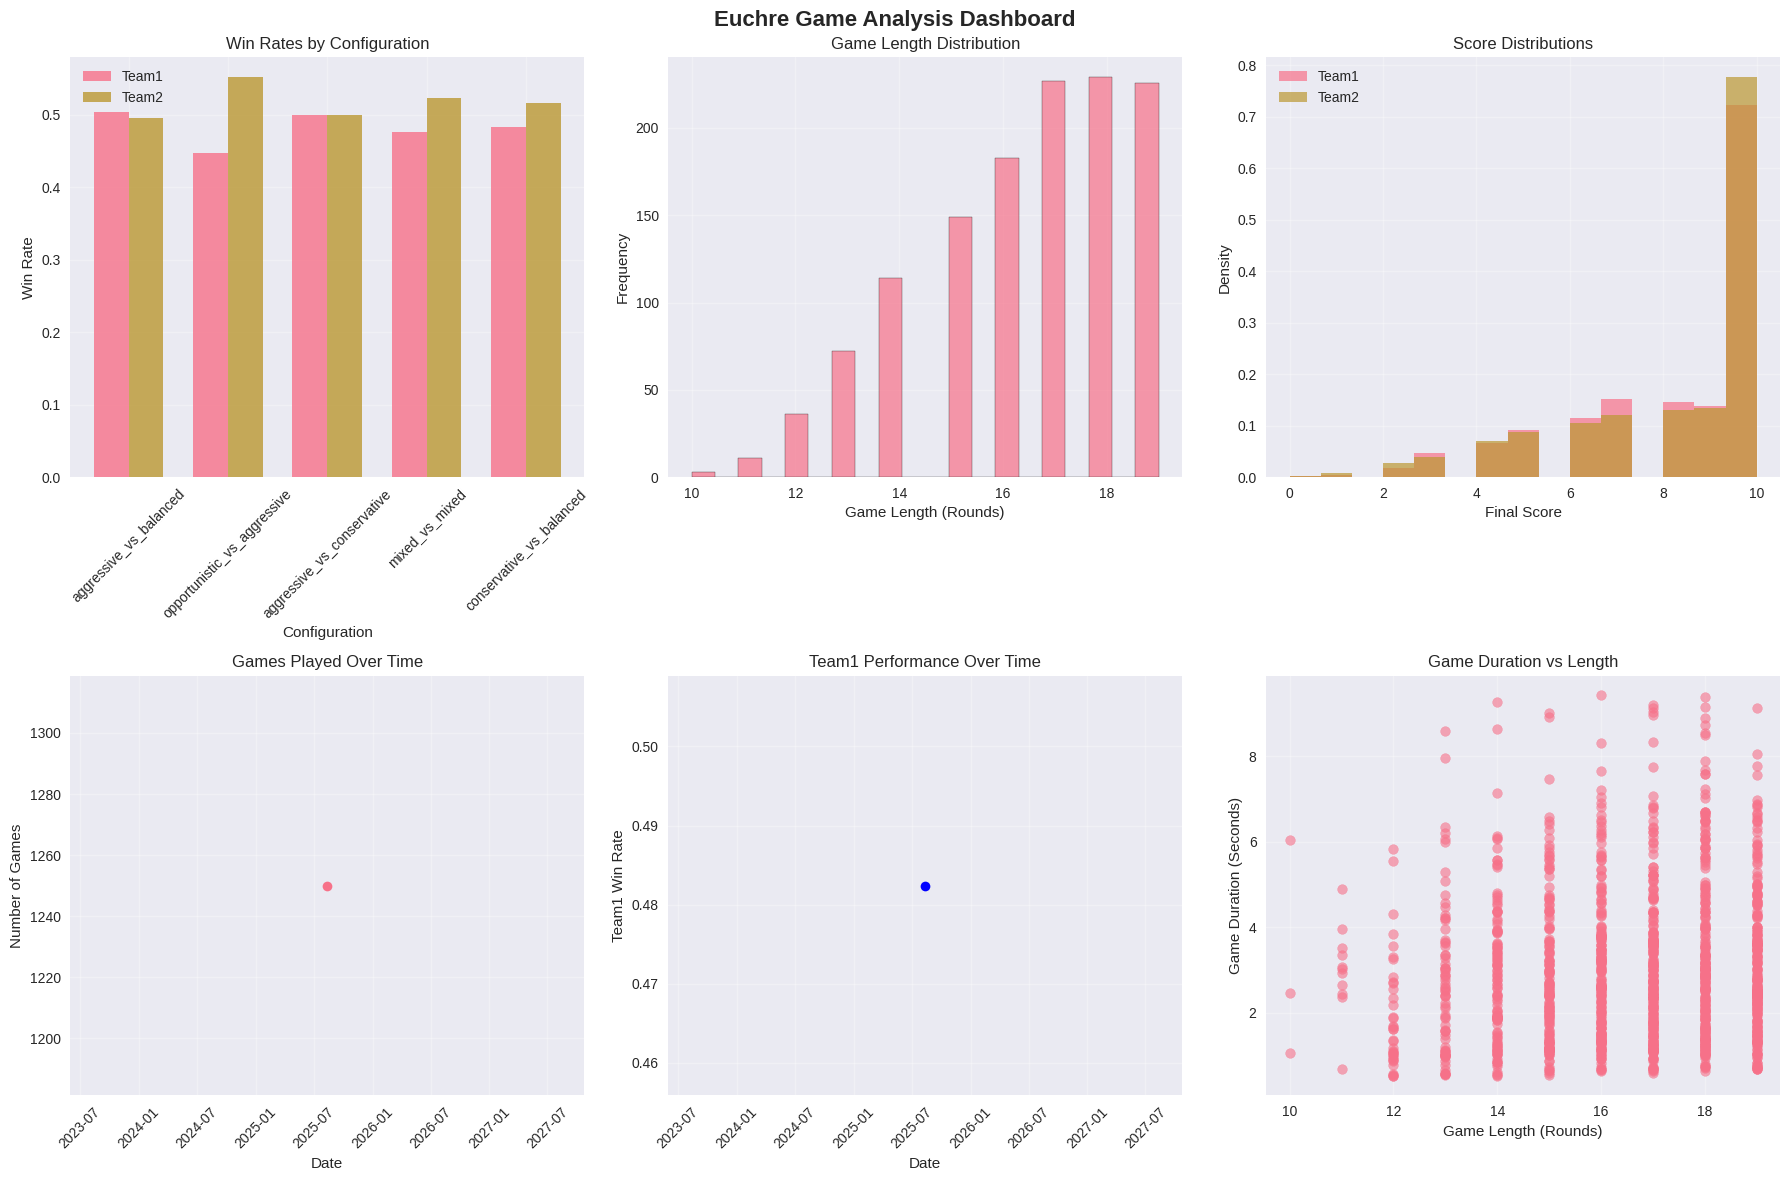

In [8]:
if 'df' in locals() and len(df) > 0:
    # Set up plotting style
    plt.style.use('seaborn-v0_8')
    sns.set_palette("husl")
    
    # Create comprehensive dashboard
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Euchre Game Analysis Dashboard', fontsize=16, fontweight='bold')
    
    # 1. Win rates by configuration
    ax1 = axes[0, 0]
    config_names = list(config_stats.keys())
    team1_rates = [config_stats[c]['team1_win_rate'] for c in config_names]
    team2_rates = [config_stats[c]['team2_win_rate'] for c in config_names]
    
    x = range(len(config_names))
    width = 0.35
    
    ax1.bar([i - width/2 for i in x], team1_rates, width, label='Team1', alpha=0.8)
    ax1.bar([i + width/2 for i in x], team2_rates, width, label='Team2', alpha=0.8)
    ax1.set_xlabel('Configuration')
    ax1.set_ylabel('Win Rate')
    ax1.set_title('Win Rates by Configuration')
    ax1.set_xticks(x)
    ax1.set_xticklabels(config_names, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Game length distribution
    ax2 = axes[0, 1]
    ax2.hist(df['total_rounds'], bins=20, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Game Length (Rounds)')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Game Length Distribution')
    ax2.grid(True, alpha=0.3)
    
    # 3. Score distributions
    ax3 = axes[0, 2]
    ax3.hist(df['team1_score'], bins=15, alpha=0.7, label='Team1', density=True)
    ax3.hist(df['team2_score'], bins=15, alpha=0.7, label='Team2', density=True)
    ax3.set_xlabel('Final Score')
    ax3.set_ylabel('Density')
    ax3.set_title('Score Distributions')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Games over time
    ax4 = axes[1, 0]
    daily_games.plot(kind='line', ax=ax4, marker='o')
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Number of Games')
    ax4.set_title('Games Played Over Time')
    ax4.grid(True, alpha=0.3)
    ax4.tick_params(axis='x', rotation=45)
    
    # 5. Performance over time
    ax5 = axes[1, 1]
    daily_performance['team1_win_rate'].plot(kind='line', ax=ax5, marker='o', color='blue')
    ax5.set_xlabel('Date')
    ax5.set_ylabel('Team1 Win Rate')
    ax5.set_title('Team1 Performance Over Time')
    ax5.grid(True, alpha=0.3)
    ax5.tick_params(axis='x', rotation=45)
    
    # 6. Game duration vs rounds
    ax6 = axes[1, 2]
    ax6.scatter(df['total_rounds'], df['game_duration'], alpha=0.6)
    ax6.set_xlabel('Game Length (Rounds)')
    ax6.set_ylabel('Game Duration (Seconds)')
    ax6.set_title('Game Duration vs Length')
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No data available for visualization")

## Export Analysis Results

In [9]:
if 'df' in locals() and len(df) > 0:
    # Export main data
    df.to_csv('euchre_game_analysis.csv', index=False)
    print("💾 Main data exported to: euchre_game_analysis.csv")
    
    # Export configuration statistics
    config_df = pd.DataFrame.from_dict(config_stats, orient='index')
    config_df.to_csv('euchre_config_analysis.csv')
    print("💾 Configuration analysis exported to: euchre_config_analysis.csv")
    
    # Export daily performance
    if 'daily_performance' in locals():
        daily_performance.to_csv('euchre_daily_performance.csv')
        print("💾 Daily performance exported to: euchre_daily_performance.csv")
    
    print("\n✅ All analysis results exported!")

💾 Main data exported to: euchre_game_analysis.csv
💾 Configuration analysis exported to: euchre_config_analysis.csv
💾 Daily performance exported to: euchre_daily_performance.csv

✅ All analysis results exported!


## Advanced Analysis: Strategy Effectiveness

In [10]:
if 'df' in locals() and len(df) > 0:
    print("🧠 ADVANCED STRATEGY ANALYSIS")
    print("=" * 50)
    
    # Analyze strategy patterns
    for config_name in df['config'].unique():
        config_df = df[df['config'] == config_name]
        
        # Performance by game length
        short_games = config_df[config_df['total_rounds'] <= config_df['total_rounds'].median()]
        long_games = config_df[config_df['total_rounds'] > config_df['total_rounds'].median()]
        
        if len(short_games) > 0 and len(long_games) > 0:
            short_team1_rate = len(short_games[short_games['winner'] == 'team1']) / len(short_games)
            long_team1_rate = len(long_games[long_games['winner'] == 'team1']) / len(long_games)
            
            print(f"\n🎯 {config_name}:")
            print(f"  Short games (≤{config_df['total_rounds'].median():.0f} rounds): Team1 wins {short_team1_rate:.1%}")
            print(f"  Long games (>={config_df['total_rounds'].median():.0f} rounds): Team1 wins {long_team1_rate:.1%}")
            
            if abs(short_team1_rate - long_team1_rate) > 0.1:
                print(f"  💡 Strategy effectiveness varies significantly with game length!")
            else:
                print(f"  📊 Strategy effectiveness is consistent across game lengths")
else:
    print("⚠️  No data available for advanced analysis")

🧠 ADVANCED STRATEGY ANALYSIS

🎯 aggressive_vs_balanced:
  Short games (≤17 rounds): Team1 wins 48.5%
  Long games (>=17 rounds): Team1 wins 54.2%
  📊 Strategy effectiveness is consistent across game lengths

🎯 opportunistic_vs_aggressive:
  Short games (≤17 rounds): Team1 wins 42.0%
  Long games (>=17 rounds): Team1 wins 49.0%
  📊 Strategy effectiveness is consistent across game lengths

🎯 aggressive_vs_conservative:
  Short games (≤17 rounds): Team1 wins 52.4%
  Long games (>=17 rounds): Team1 wins 45.2%
  📊 Strategy effectiveness is consistent across game lengths

🎯 mixed_vs_mixed:
  Short games (≤17 rounds): Team1 wins 46.6%
  Long games (>=17 rounds): Team1 wins 49.4%
  📊 Strategy effectiveness is consistent across game lengths

🎯 conservative_vs_balanced:
  Short games (≤17 rounds): Team1 wins 51.7%
  Long games (>=17 rounds): Team1 wins 43.4%
  📊 Strategy effectiveness is consistent across game lengths
